In [ ]:
%%html
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:wght@300;400;500;600;700&display=swap" rel="stylesheet">

<style>
/* markdown + output */
body, .markdown-body, .jp-RenderedHTMLCommon, div.text_cell_render,
.notebook, .notebook * {
  font-family: "Source Serif 4", serif !important;
}

/* code editor (monaco) */
.monaco-editor, .monaco-editor * {
  font-family: "Source Serif 4", serif !important;
}
</style>

In [ ]:
import scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import os
from scipy.stats import *
from scipy.stats import norm, t, binom, poisson, expon
import numpy as np
from numpy import random
from matplotlib import pyplot as plt

### population vs sample

**population**
- data collected from ALL possible sources
- example: all people voting in general election

**sample**
- data collected from subset of population
- example: people contacted for survey (always a subset)

**parameter**
- the variable for which data is collected

**data**
- numbers collected for parameters

**population parameter (PP)**
- summary of data from entire population
- example: general election result

**sample statistic (SS)**
- summary of data from sample
- example: exit poll result

**relationship:**

$$SS = PP + \text{Bias} + \text{Chance Variation}$$

- SS = PP → claim (ideal but unrealistic)
- SS ≠ PP → reality (what actually happens)

**note:** chance variation can only be eliminated when sample size = population size (which rarely happens in practice)

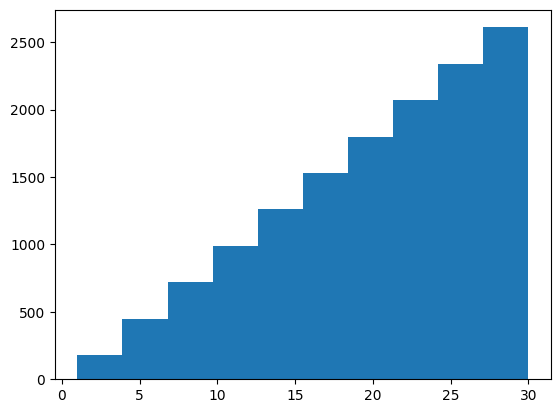

20.28853
0.3335889492102158


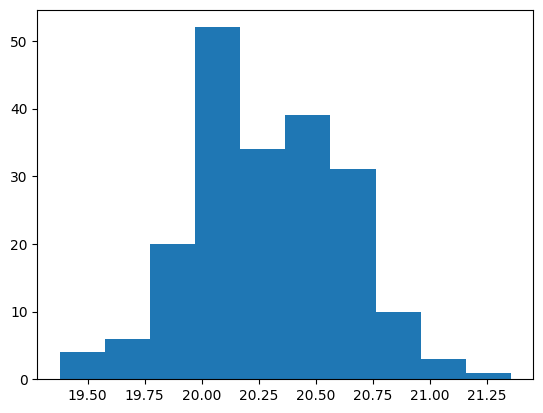

In [ ]:
# demonstration of central limit theorem

# create skewed population distribution
x1 = np.repeat(np.arange(1, 31), np.arange(10, 310, 10))
x1 = np.repeat(x1, 3)

# plot original population (skewed)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(x1, bins=30, edgecolor='black', alpha=0.7)
plt.title('original population distribution (skewed)')
plt.xlabel('value')
plt.ylabel('frequency')

# draw 200 samples, each of size 500
m = []
for ctr1 in range(1, 201):
    val = np.random.choice(x1, 500)
    m.append(val)

# calculate mean of each sample
mean_m = []
for ctr1 in range(len(m)):
    mean_m.append(np.mean(m[ctr1]))

# plot sampling distribution of means (normal)
plt.subplot(1, 2, 2)
plt.hist(mean_m, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.title('sampling distribution of means (normal)')
plt.xlabel('sample mean')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

print(f'population is skewed, but sample means are normally distributed')

### central limit theorem (CLT)

as the number of samples increases, the distribution of sample means approaches a normal distribution. this is true regardless of the original population distribution.

**key insight:** even if the population is skewed, the sample means will be normally distributed when you have enough samples.

In [ ]:
# summary statistics of sampling distribution
print(f'mean of sample means: {np.mean(mean_m):.4f}')
print(f'std of sample means: {np.std(mean_m, ddof=1):.4f}')
print(f'\nthis std is called standard error (SE)')

20.28853
0.3335889492102158


The `ddof` parameter in `np.std()` stands for **Delta Degrees of Freedom**.

- By default, `np.std(..., ddof=0)` calculates the **population standard deviation** (divides by N).
- If you set `ddof=1`, it calculates the **sample standard deviation** (divides by N-1), which is an unbiased estimator for the standard deviation of a population from a sample.

**In summary:**
- `np.std(mean_m, ddof=0)` → population std (divide by N)
- `np.std(mean_m, ddof=1)` → sample std (divide by N-1, unbiased)

**Why use `ddof=1`?**
When you have a sample and want to estimate the population standard deviation, use `ddof=1`.

---

#### Central Limit Theorem (Sample Mean) and the 95% Z-Interval

#### Concept
When the sample size is reasonably large, the sampling distribution of the sample mean (x̄) becomes approximately normal with:

- Mean μ (use the symbol directly, e.g. μ = 0.95)
- Standard error SE given by the formula below.

$$
\text{SE} = \frac{\sigma}{\sqrt{n}}
$$

---

<a href="https://freeimage.host/i/fnBJxeV" target="_blank">
  <img src="https://iili.io/fnBJxeV.md.png" alt="CLT Illustration" style="width:60%;">
</a>

#### Standard Normal Inequality for 95% Confidence

The 95% standard normal interval is:

$$
-1.96 \le Z \le +1.96
$$

where

$$
Z = \frac{\bar{X} - \mu}{\text{SE}}
$$

---

#### Converting Z-Interval to x̄-Interval

Start with:

$$
-1.96 \le \frac{\bar{X} - \mu}{\text{SE}} \le 1.96
$$

Multiply by SE and add μ:

$$
\mu - 1.96\cdot\text{SE} \le \bar{X} \le \mu + 1.96\cdot\text{SE}
$$

This is the 95% confidence interval for the sample mean.

---

#### Numerical Example (use direct signs for single-line values)

- Mean μ = 0.95  
- Population standard deviation σ = 1.0 (assumed)  
- Sample size n = 30

Compute SE:

$$
\text{SE} = \frac{1}{\sqrt{30}} \approx 0.1826
$$

Lower bound:

$$
0.95 - 1.96 \times 0.1826 \approx 0.592
$$

Upper bound:

$$
0.95 + 1.96 \times 0.1826 \approx 1.308
$$

So the 95% confidence interval for the sample mean is:

$$
0.592 \le \bar{X} \le 1.308
$$

---

#### Interpretation
- Curve: sampling distribution of the sample mean under CLT.  
- Center line: mean μ = 0.95 (written with the μ symbol directly).  
- Shaded region: central 95% of possible sample means.  
- Vertical dotted lines: lower and upper bounds of the 95% interval.

Meaning: if you repeatedly take samples of size n = 30, about 95% of the sample means will lie between 0.592 and 1.308.

confidence = 95%

significance becomes rest - 5%

---

#### Intuition (single-line symbols)
- z critical values: za = -1.96, zb = +1.96  
- SE = σ / √n  
- CI for x̄: μ ± 1.96·SE



In [ ]:
# confidence interval using normal distribution (z-interval)
# formula: x̄ ± z * (σ/√n)

n = 100  # sample size
sm = 45.7  # sample mean
pop_sd = 6.8  # population standard deviation
cl = 0.95  # 95% confidence level

# find z-critical values for 95% CI
za = norm.ppf(0.025)  # lower tail (2.5%)
zb = norm.ppf(0.975)  # upper tail (97.5%)

# calculate confidence interval bounds
se = pop_sd / n**0.5  # standard error
low_est = sm + za * se
upper_est = sm + zb * se

print(f'sample mean = {sm}')
print(f'standard error = {se:.4f}')
print(f'z-critical values: {za:.4f}, {zb:.4f}')
print(f'95% CI: [{low_est:.4f}, {upper_est:.4f}]')

In [ ]:
low_est  # lower bound: 2.5% probability of being less than this value

np.float64(44.36722449051277)

In [ ]:
upper_est  # upper bound: 2.5% probability of being more than this value

np.float64(47.03277550948724)

In [ ]:
# margin of error (MOE) = upper_est - lower_est = 2 * z * σ/√n
moe = upper_est - low_est
print(f'margin of error = {moe:.4f}')
print(f'also equals: 2 * {zb:.4f} * {se:.4f} = {2 * zb * se:.4f}')

### factors affecting margin of error (MOE)

the margin of error depends on three main factors:

#### 1. sample size (n)
- as sample size increases → MOE decreases
- relationship: MOE ∝ 1/√n

#### 2. standard deviation (σ)
- as data becomes more consistent (σ decreases) → MOE decreases
- relationship: MOE ∝ σ

#### 3. confidence level
- as confidence level increases → z increases → MOE increases
- common z-values:
  - 90% CI: z = 1.645
  - 95% CI: z = 1.96
  - 99% CI: z = 2.576

**formula:** MOE = z × σ/√n

In [ ]:
# using scipy built-in function for t-distribution CI
# note: slight difference from z-interval because uses t-distribution
scipy.stats.t.interval(cl, n-1, sm, pop_sd/n**0.5)

(np.float64(44.3507324729741), np.float64(47.049267527025904))

In [ ]:
# confidence interval using t-distribution (t-interval)
# use t-distribution when population σ is unknown or n < 30
# formula: x̄ ± t * (s/√n)

n = 100
sm = 45.7
pop_sd = 6.8
cl = 0.95
df = n - 1  # degrees of freedom

# find t-critical values
za = t.ppf((1-cl)/2, df)  # lower tail
zb = t.ppf(cl + (1-cl)/2, df)  # upper tail

# calculate CI
se = pop_sd / n**0.5
low_est = sm + za * se
upper_est = sm + zb * se

print(f't-critical values: {za:.4f}, {zb:.4f}')
print(f'95% t-interval: [{low_est:.4f}, {upper_est:.4f}]')

In [ ]:
low_est  # lower bound of 95% t-interval

np.float64(44.3507324729741)

In [ ]:
upper_est  # upper bound of 95% t-interval

np.float64(47.049267527025904)

In [ ]:
# confidence interval for proportion
# formula: p̂ ± z * √(p̂(1-p̂)/n)

n = 500  # total population surveyed
r = 200  # total positive responses
p = r / n  # sample proportion

# standard deviation for proportion
sd = (p * (1 - p)) ** 0.5

# 95% CI for proportion
z_critical = 1.96
se = sd / n**0.5
low_est = p - z_critical * se
upper_est = p + z_critical * se

print(f'sample proportion p̂ = {p:.4f} ({p*100:.1f}%)')
print(f'standard deviation = {sd:.4f}')
print(f'standard error = {se:.4f}')
print(f'95% CI: [{low_est:.4f}, {upper_est:.4f}]')
print(f'interpretation: true proportion lies between {low_est*100:.2f}% and {upper_est*100:.2f}%')

0.4898979485566356


In [ ]:
(p * (1 - p)) ** 0.5  # standard deviation for proportion formula

0.4898979485566356

In [ ]:
low_est  # lower bound of proportion CI

0.357058551491595

In [ ]:
upper_est  # upper bound of proportion CI

0.44294144850840506

In [ ]:
from scipy.stats import rv_discrete  # for discrete random variables

In [ ]:
# confidence interval for poisson distribution
# when count data follows poisson distribution with mean λ = 20
# formula: uses ppf to find bounds

lambda_val = 20
ci = scipy.stats.poisson.interval(0.95, lambda_val)
print(f'95% CI for poisson(λ={lambda_val}): {ci}')
print(f'interpretation: 95% of counts will be between {ci[0]} and {ci[1]}')

(np.float64(12.0), np.float64(29.0))

In [ ]:
poisson.ppf(0.025, 20)  # lower 2.5% percentile

np.float64(12.0)

In [ ]:
poisson.ppf(0.975, 20)  # upper 97.5% percentile

np.float64(29.0)

---

### hypothesis testing

hypothesis testing is a statistical method to make decisions about population parameters based on sample data.

**key concepts:**
- null hypothesis (H₀): the claim we assume is true (status quo)
- alternative hypothesis (H₁ or Hₐ): what we want to prove
- p-value: probability of getting observed results if H₀ is true
- significance level (α): maximum acceptable probability of type I error

### type I and type II errors

**reducing both errors:**
- the only way to decrease both types of errors is to increase the sample size
- as sample size → population size, errors → 0
- theoretically, there are no errors when sample size = population size (but this is impractical in real-world scenarios)

### understanding the two types of errors

#### type I error: reject true H₀ (false positive)
- scenario: bad sample but good population
- probability = α (significance level)
- example: rejecting a good product because of a bad sample

#### type II error: fail to reject false H₀ (false negative)
- scenario: good sample but bad population
- probability = β (power = 1 - β)
- example: accepting a bad product because the sample happened to be good

### steps in hypothesis testing

#### step 1: establish null (H₀) and alternative (H₁) hypotheses

the null hypothesis represents the status quo - if found true, no action/decision/changes are required.

**three types of tests based on alternative hypothesis:**

#### case 1: left tail test
- example: salary analysis
- H₀: salary >= 10 LPA
- H₁: salary < 10 LPA
- rejection region: left side (lower tail)

#### case 2: right tail test
- example: delivery time
- H₀: time <= 30 min
- H₁: time > 30 min
- rejection region: right side (upper tail)

#### case 3: two tail test
- example: salt content in food
- H₀: salt = 2 grams
- H₁: salt ≠ 2 grams
- rejection region: both sides

---

#### step 2: establish confidence level and significance level (α)

- significance level (α) = 100% - confidence level
- common values:
  - α = 0.05 (95% confidence)
  - α = 0.01 (99% confidence)

---

#### step 3: choose appropriate statistical test

- **z-test:** large sample, known σ
- **t-test:** small sample, unknown σ
- **chi-square:** categorical data
- **ANOVA:** compare multiple groups

---

#### step 4: calculate test statistic and p-value

use python functions to compute these values.

---

#### step 5: make decision

- if p-value < α: reject H₀
- if p-value >= α: fail to reject H₀

---

### interpretation of p-value and α

**α (level of significance):** maximum allowed probability of type I error

**p-value:** actual probability of type I error given the data

---

### practical analogy: covid safety decision

imagine deciding whether to go out during covid:

- **H₀:** stay at home (safe option)
- **H₁:** move out
- **p-value:** probability of infection if moving out (from tracking app)
- **α:** maximum acceptable infection risk (recommended by doctor) = 0.05

#### scenario 1: p-value = 0.20
- p-value > α, so **do not reject H₀** (stay home)
- interpretation: 20% risk > 5% acceptable risk → too risky to go out

#### scenario 2: p-value = 0.02
- p-value < α, so **reject H₀** (can move out)
- interpretation: 2% risk < 5% acceptable risk → safe enough to go out

In [147]:
# z-critical value for left tail test at α = 0.10
z_crit = norm.ppf(0.1)
print(f'z-critical = {z_crit:.4f}')
print(f'if test statistic < {z_crit:.4f}, reject H₀')

np.float64(-1.2815515655446004)

### types of null hypotheses and tests

#### 1. one-sample tests
- test a single population parameter
- examples:
  - H₀: μ = μ₀
  - H₀: μ >= μ₀
  - H₀: μ <= μ₀

#### 2. two-sample tests
- compare two populations
- examples:
  - H₀: μ₁ = μ₂
  - H₀: μ₁ - μ₂ = 0

#### 3. paired tests
- compare before/after measurements on same subjects
- H₀: μ_diff = 0

#### 4. proportion tests
- test population proportion
- H₀: p = p₀

#### 5. variance tests
- test population variance
- H₀: σ² = σ₀²

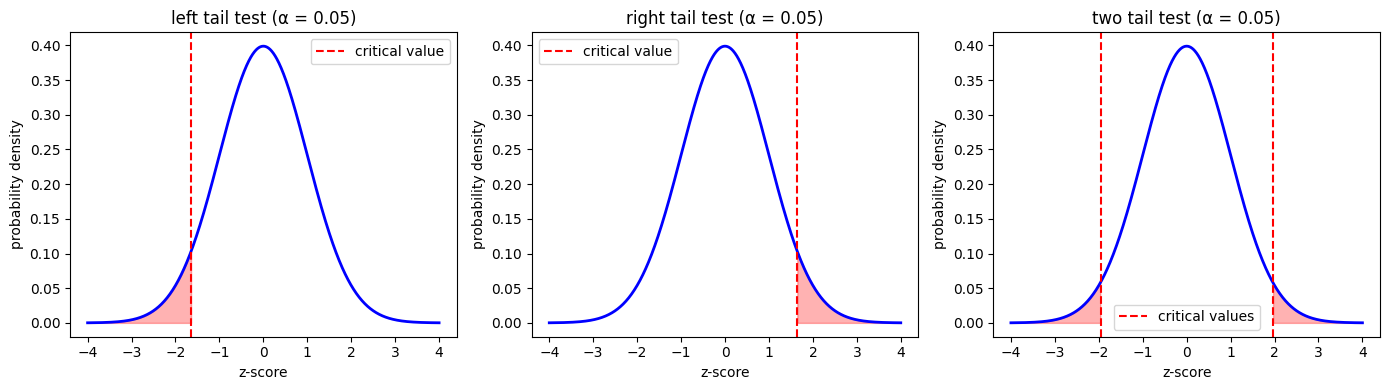

In [149]:
# visualization of hypothesis testing regions
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(14, 4))

# left tail test
plt.subplot(1, 3, 1)
plt.plot(x, y, 'b-', linewidth=2)
plt.fill_between(x[x < -1.645], y[x < -1.645], alpha=0.3, color='red')
plt.axvline(-1.645, color='red', linestyle='--', label='critical value')
plt.title('left tail test (α = 0.05)')
plt.xlabel('z-score')
plt.ylabel('probability density')
plt.legend()

# right tail test
plt.subplot(1, 3, 2)
plt.plot(x, y, 'b-', linewidth=2)
plt.fill_between(x[x > 1.645], y[x > 1.645], alpha=0.3, color='red')
plt.axvline(1.645, color='red', linestyle='--', label='critical value')
plt.title('right tail test (α = 0.05)')
plt.xlabel('z-score')
plt.ylabel('probability density')
plt.legend()

# two tail test
plt.subplot(1, 3, 3)
plt.plot(x, y, 'b-', linewidth=2)
plt.fill_between(x[x < -1.96], y[x < -1.96], alpha=0.3, color='red')
plt.fill_between(x[x > 1.96], y[x > 1.96], alpha=0.3, color='red')
plt.axvline(-1.96, color='red', linestyle='--', label='critical values')
plt.axvline(1.96, color='red', linestyle='--')
plt.title('two tail test (α = 0.05)')
plt.xlabel('z-score')
plt.ylabel('probability density')
plt.legend()

plt.tight_layout()
plt.show()